# 02 — Exploratory Data Analysis & Feature Engineering
Load the raw data, clean it, visualize patterns, and build the features the model will use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load & Merge Raw Data

In [3]:
aqi_df = pd.read_csv('../data/raw/aqi_raw.csv', parse_dates=['date'])
weather_df = pd.read_csv('../data/raw/weather_raw.csv', parse_dates=['date'])

df = aqi_df[['date', 'aqi']].merge(weather_df, on='date', how='inner')
df = df.sort_values('date').reset_index(drop=True)

print(f'Merged shape: {df.shape}')
df.head()

Merged shape: (251, 7)


,date,aqi,wind_ms,prcp_mm,tmax_c,tmin_c,tavg_c
0,2024-01-01,71,1.2,0.0,8.3,1.1,4.70
1,2024-01-02,65,1.7,6.1,8.3,3.3,5.80
2,2024-01-03,51,3.3,2.5,10.0,5.0,7.50
3,2024-01-04,36,2.6,3.6,7.8,5.0,6.40
4,2024-01-05,53,6.1,5.8,8.3,4.4,6.35


## 2. Handle Missing Values

In [4]:
print('Missing values per column:')
print(df.isnull().sum())

# Strategy: forward-fill AQI gaps up to 2 days (common with sensor outages)
# then drop any remaining NaN rows
df['aqi'] = df['aqi'].ffill(limit=2)

# Fill weather gaps with column median (rare missing days)
weather_cols = ['tmax_c', 'tmin_c', 'tavg_c', 'prcp_mm', 'wind_ms']
for col in weather_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df = df.dropna()
print(f'\nShape after cleaning: {df.shape}')

Missing values per column:
date       0
aqi        0
wind_ms    0
prcp_mm    2
tmax_c     0
tmin_c     2
tavg_c     2
dtype: int64

Shape after cleaning: (251, 7)


## 3. Visualize AQI Over Time

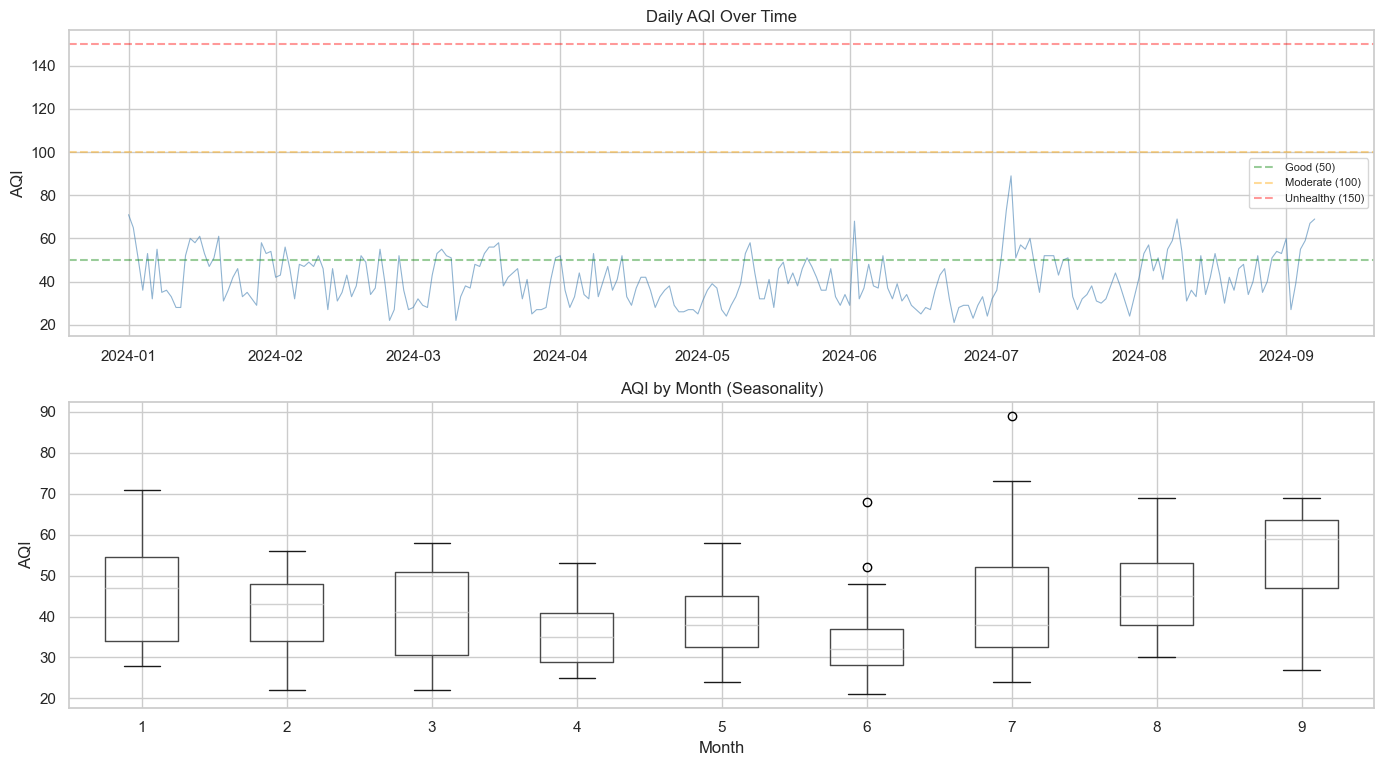

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Time series
ax = axes[0]
ax.plot(df['date'], df['aqi'], alpha=0.6, linewidth=0.8, color='steelblue')
ax.axhline(50,  color='green',  alpha=0.4, linestyle='--', label='Good (50)')
ax.axhline(100, color='orange', alpha=0.4, linestyle='--', label='Moderate (100)')
ax.axhline(150, color='red',    alpha=0.4, linestyle='--', label='Unhealthy (150)')
ax.set_title('Daily AQI Over Time')
ax.set_ylabel('AQI')
ax.legend(fontsize=8)

# Monthly box plot — seasonality
ax2 = axes[1]
df['month'] = df['date'].dt.month
df.boxplot(column='aqi', by='month', ax=ax2)
ax2.set_title('AQI by Month (Seasonality)')
ax2.set_xlabel('Month')
ax2.set_ylabel('AQI')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Correlation: Weather vs AQI

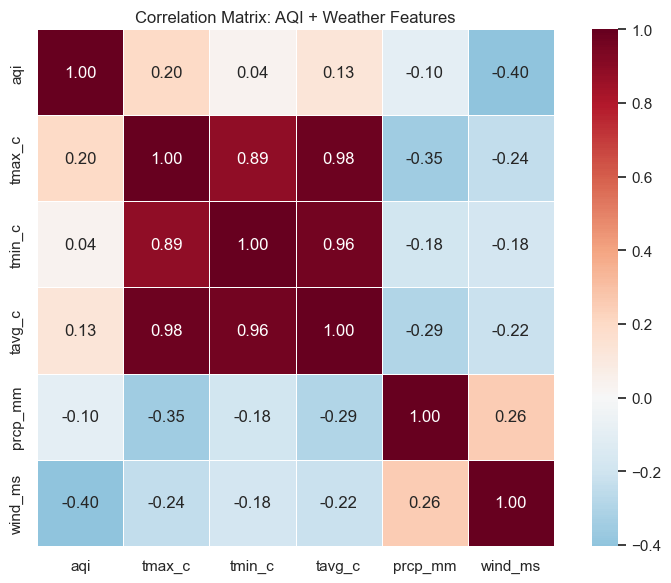


Correlation with AQI:
tmax_c     0.198826
tavg_c     0.131461
tmin_c     0.040910
prcp_mm   -0.097954
wind_ms   -0.402144
Name: aqi, dtype: float64


In [6]:
weather_available = [c for c in weather_cols if c in df.columns]
corr = df[['aqi'] + weather_available].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix: AQI + Weather Features')
plt.tight_layout()
plt.show()

print('\nCorrelation with AQI:')
print(corr['aqi'].drop('aqi').sort_values(ascending=False))

## 5. Feature Engineering
This is the key step — we create features that give the model useful signals.

In [7]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add lag, rolling, and calendar features to the dataframe."""
    df = df.copy().sort_values('date').reset_index(drop=True)

    # --- Lag features: past AQI values ---
    # The single best predictor of tomorrow's AQI is yesterday's AQI
    df['aqi_lag1'] = df['aqi'].shift(1)   # yesterday
    df['aqi_lag2'] = df['aqi'].shift(2)   # 2 days ago
    df['aqi_lag3'] = df['aqi'].shift(3)   # 3 days ago
    df['aqi_lag7'] = df['aqi'].shift(7)   # same day last week

    # --- Rolling statistics ---
    df['aqi_roll7']  = df['aqi'].shift(1).rolling(7).mean()   # 7-day rolling avg
    df['aqi_roll14'] = df['aqi'].shift(1).rolling(14).mean()  # 14-day rolling avg
    df['aqi_roll7_std'] = df['aqi'].shift(1).rolling(7).std() # 7-day volatility

    # --- Calendar features ---
    df['day_of_week'] = df['date'].dt.dayofweek   # 0=Monday, 6=Sunday
    df['month']       = df['date'].dt.month
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    # Wildfire season proxy (summer/fall in western US)
    df['wildfire_season'] = df['month'].isin([7, 8, 9, 10]).astype(int)

    # --- Target: next day's AQI ---
    df['target_aqi'] = df['aqi'].shift(-1)

    # Drop rows with NaN from lag/rolling (first ~14 rows and last row)
    df = df.dropna().reset_index(drop=True)
    return df


df_feat = build_features(df)
print(f'Feature matrix shape: {df_feat.shape}')
df_feat.head()

Feature matrix shape: (236, 19)


,date,aqi,wind_ms,prcp_mm,tmax_c,tmin_c,tavg_c,month,aqi_lag1,aqi_lag2,aqi_lag3,aqi_lag7,aqi_roll7,aqi_roll14,aqi_roll7_std,day_of_week,is_weekend,wildfire_season,target_aqi
0,2024-01-15,58,3.8,0.0,3.3,-6.0,-1.35,1,60.0,52.0,28.0,35.0,38.857143,45.357143,12.334620,0,0,0,61.0
1,2024-01-16,61,2.6,1.8,2.2,-5.5,-1.65,1,58.0,60.0,52.0,36.0,42.142857,44.428571,14.076323,1,0,0,53.0
2,2024-01-17,53,3.3,7.1,4.4,-1.0,1.70,1,61.0,58.0,60.0,33.0,45.714286,44.142857,15.370039,2,0,0,47.0
3,2024-01-18,47,5.1,9.7,3.9,1.1,2.50,1,53.0,61.0,58.0,28.0,48.571429,44.285714,14.443651,3,0,0,51.0
4,2024-01-19,51,3.6,0.5,8.3,2.8,5.55,1,47.0,53.0,61.0,28.0,51.285714,45.071429,11.397577,4,0,0,61.0


In [8]:
# Save processed data for the modeling notebook
import os
os.makedirs('../data/processed', exist_ok=True)
df_feat.to_csv('../data/processed/features.csv', index=False)
print('Saved to data/processed/features.csv')

feature_cols = [
    'aqi_lag1', 'aqi_lag2', 'aqi_lag3', 'aqi_lag7',
    'aqi_roll7', 'aqi_roll14', 'aqi_roll7_std',
    'day_of_week', 'month', 'is_weekend', 'wildfire_season',
]
# Add weather features if present
feature_cols += [c for c in ['tavg_c', 'tmax_c', 'tmin_c', 'prcp_mm', 'wind_ms']
                 if c in df_feat.columns]

print('\nFinal feature list:')
for f in feature_cols:
    print(f'  {f}')

Saved to data/processed/features.csv

Final feature list:
  aqi_lag1
  aqi_lag2
  aqi_lag3
  aqi_lag7
  aqi_roll7
  aqi_roll14
  aqi_roll7_std
  day_of_week
  month
  is_weekend
  wildfire_season
  tavg_c
  tmax_c
  tmin_c
  prcp_mm
  wind_ms


In [10]:
print(df_feat[['tavg_c', 'tmax_c', 'tmin_c', 'prcp_mm', 'wind_ms']].describe())

           tavg_c      tmax_c      tmin_c     prcp_mm     wind_ms
count  236.000000  236.000000  236.000000  236.000000  236.000000
mean    13.360169   17.838559    8.862712    1.711864    3.575847
std      5.868098    7.359781    4.754748    3.689310    1.075159
min     -1.650000    2.200000   -6.000000    0.000000    1.500000
25%      8.900000   11.700000    5.600000    0.000000    2.800000
50%     12.925000   17.200000    8.300000    0.000000    3.400000
75%     18.350000   23.900000   13.300000    1.350000    4.025000
max     27.250000   36.700000   19.400000   24.100000    7.400000
